In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import glob
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

FIGURES_DIR = 'raport/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

CLASSES   = ['F0', 'F1', 'F2', 'F3', 'F4']
N_CLASSES = len(CLASSES)

Device: cuda


In [2]:
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_ds     = datasets.ImageFolder('dataset_split/test', transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
print(f'Test set: {len(test_ds)} images')

Test set: 954 images


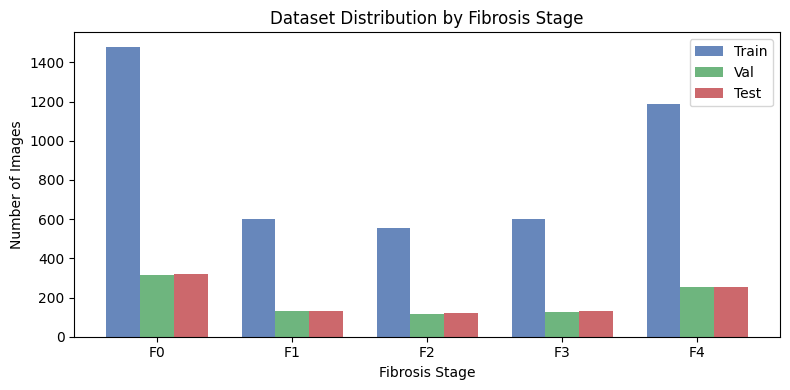

Saved class_distribution.png


In [3]:
splits = {'Train': 'dataset_split/train', 'Val': 'dataset_split/val', 'Test': 'dataset_split/test'}
counts = {split: [len(glob.glob(f'{path}/{c}/*')) for c in CLASSES] for split, path in splits.items()}

x      = np.arange(N_CLASSES)
width  = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 4))
for i, (split, color) in enumerate(zip(splits, colors)):
    ax.bar(x + i * width, counts[split], width, label=split, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES)
ax.set_xlabel('Fibrosis Stage')
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Distribution by Fibrosis Stage')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/class_distribution.png', dpi=150)
plt.show()
print('Saved class_distribution.png')

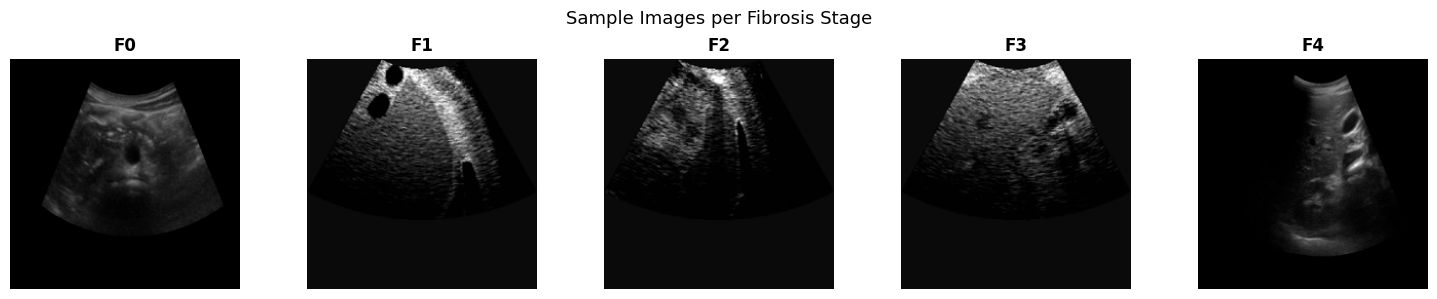

Saved sample_images.png


In [4]:
fig, axes = plt.subplots(1, N_CLASSES, figsize=(15, 3))
for ax, cls in zip(axes, CLASSES):
    img_path = glob.glob(f'dataset_split/test/{cls}/*')[0]
    img      = Image.open(img_path).convert('RGB').resize((224, 224))
    ax.imshow(img, cmap='gray')
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Images per Fibrosis Stage', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/sample_images.png', dpi=150)
plt.show()
print('Saved sample_images.png')

In [5]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            preds = torch.argmax(model(inputs.to(device)), dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    acc      = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    cm       = confusion_matrix(y_true, y_pred)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1, 'cm': cm}


def save_confusion_matrix(cm, title, filename):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/{filename}', dpi=150)
    plt.show()
    print(f'Saved {filename}')

ResNet-18 Pretrained: acc=0.9193  f1=0.8884
ResNet-18 Scratch: acc=0.8700  f1=0.8230


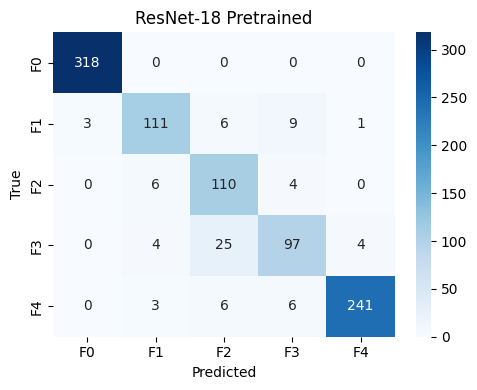

Saved cm_resnet_pretrained.png


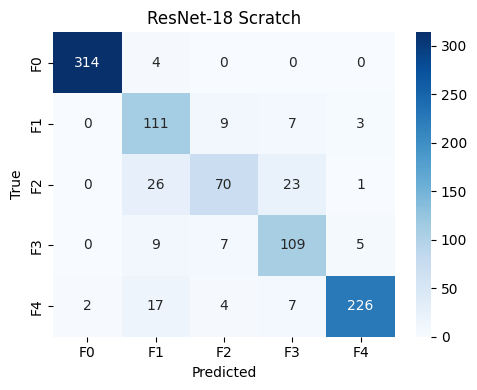

Saved cm_resnet_scratch.png


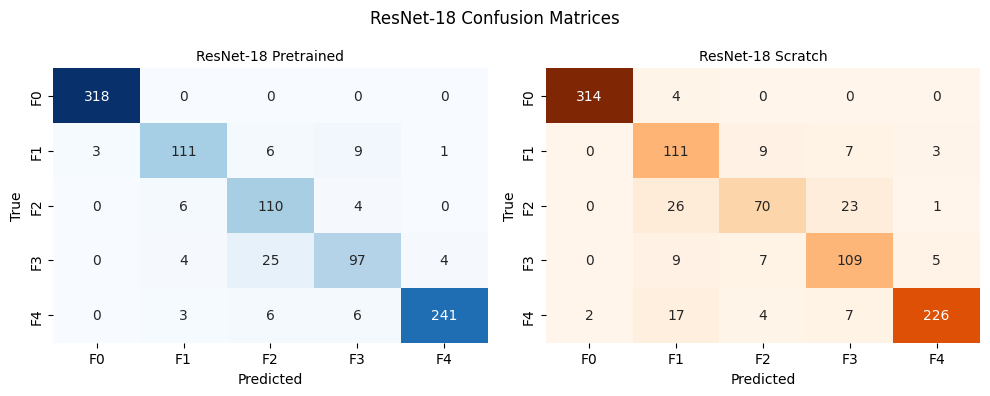

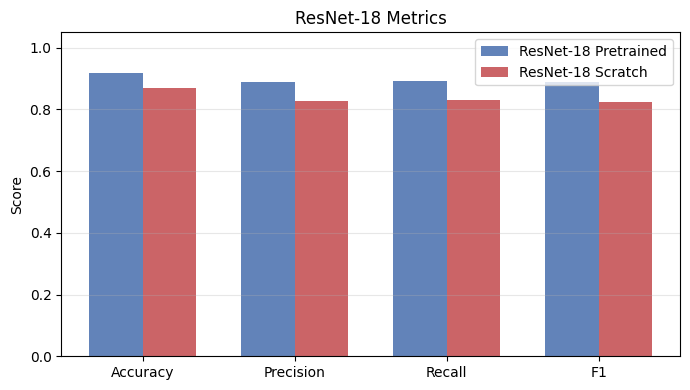

ResNet figures saved.


In [6]:
results = {}

for name, weights_path in [('ResNet-18 Pretrained', 'model_fibroza_pretrained.pth'),
                             ('ResNet-18 Scratch',   'model_fibroza_scratch.pth')]:
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, N_CLASSES)
    m.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    m = m.to(device)
    results[name] = evaluate(m, test_loader)
    print(f'{name}: acc={results[name]["accuracy"]:.4f}  f1={results[name]["f1"]:.4f}')

save_confusion_matrix(results['ResNet-18 Pretrained']['cm'], 'ResNet-18 Pretrained', 'cm_resnet_pretrained.png')
save_confusion_matrix(results['ResNet-18 Scratch']['cm'],   'ResNet-18 Scratch',    'cm_resnet_scratch.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, cmap in zip(axes, ['ResNet-18 Pretrained', 'ResNet-18 Scratch'], ['Blues', 'Oranges']):
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(name, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('ResNet-18 Confusion Matrices', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cm_resnet_group.png', dpi=150)
plt.show()

metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics)); width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#C44E52']
for i, (name, color) in enumerate(zip(['ResNet-18 Pretrained', 'ResNet-18 Scratch'], colors)):
    ax.bar(x + i * width, [results[name][m] for m in metrics], width, label=name, color=color, alpha=0.88)
ax.set_xticks(x + width / 2); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('ResNet-18 Metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/metrics_resnet.png', dpi=150)
plt.show()
print('ResNet figures saved.')

/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/vlad/miniconda3/envs/proiect/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


initialize_weights...
MedViT-V1 Small: acc=0.9182  f1=0.8849
initialize_weights...
MedViT-V1 Base: acc=0.9843  f1=0.9772
initialize_weights...
MedViT-V1 Large: acc=0.9654  f1=0.9496


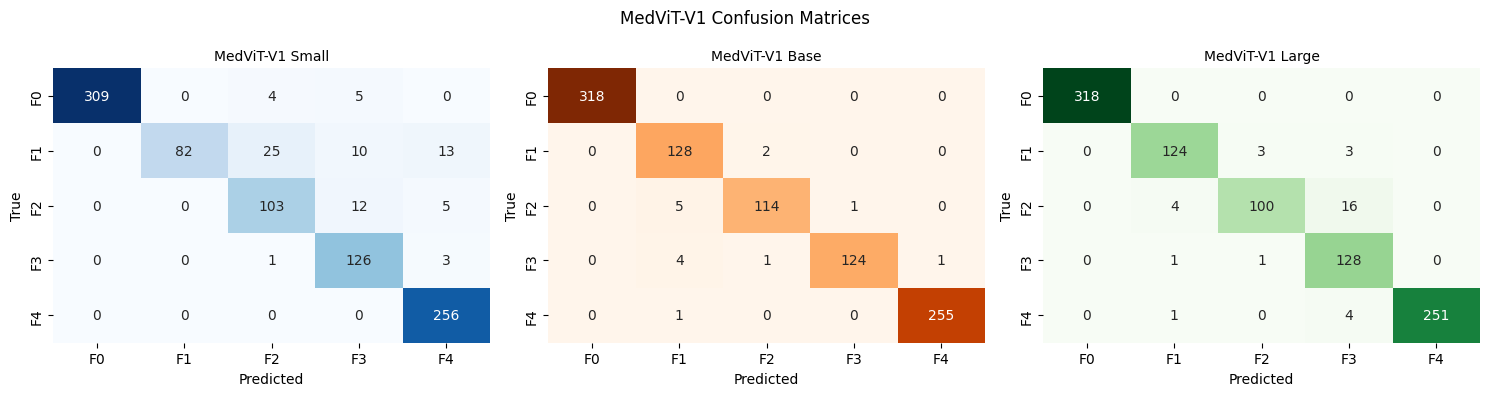

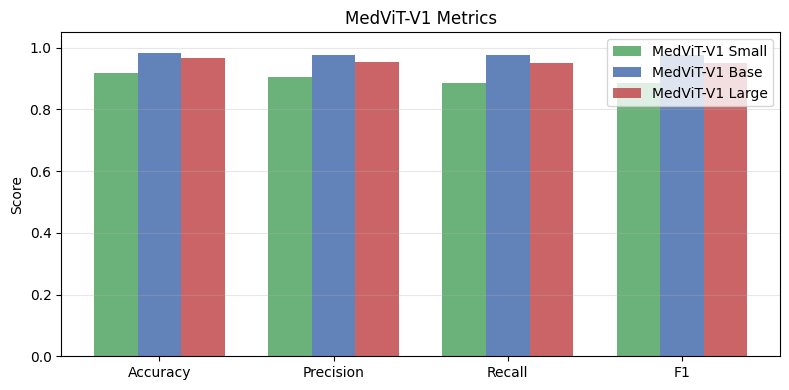

MedViT-V1 figures saved.


In [7]:
import importlib
for mod in list(sys.modules.keys()):
    if 'MedViT' in mod:
        del sys.modules[mod]

v2_path = os.path.abspath('MedViTV2')
if v2_path in sys.path:
    sys.path.remove(v2_path)
if os.path.abspath('MedViT') not in sys.path:
    sys.path.insert(0, os.path.abspath('MedViT'))

from MedViT import MedViT_small as V1_small, MedViT_base as V1_base, MedViT_large as V1_large

v1_entries = [
    ('MedViT-V1 Small', V1_small, 'checkpoints/medvit_small_epoch20.pth'),
    ('MedViT-V1 Base',  V1_base,  'checkpoints/medvit_base_epoch20.pth'),
    ('MedViT-V1 Large', V1_large, 'medvit_large.pth'),
]
v1_names = []
for name, cls, path in v1_entries:
    m = cls(num_classes=N_CLASSES)
    m.load_state_dict(torch.load(path, map_location='cpu', weights_only=False))
    m = m.to(device)
    results[name] = evaluate(m, test_loader)
    v1_names.append(name)
    print(f'{name}: acc={results[name]["accuracy"]:.4f}  f1={results[name]["f1"]:.4f}')

cmaps = ['Blues', 'Oranges', 'Greens']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, cmap in zip(axes, v1_names, cmaps):
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(name, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('MedViT-V1 Confusion Matrices', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/cm_medvit_v1_group.png', dpi=150)
plt.show()

x = np.arange(len(metrics)); width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#55A868', '#4C72B0', '#C44E52']
for i, (name, color) in enumerate(zip(v1_names, colors)):
    ax.bar(x + i * width, [results[name][m] for m in metrics], width, label=name, color=color, alpha=0.88)
ax.set_xticks(x + width); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('MedViT-V1 Metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/metrics_medvit_v1.png', dpi=150)
plt.show()
print('MedViT-V1 figures saved.')

/home/vlad/Documents/facultate/proiect/MedViTV2/MedViT.py:583: UserWarning: Overwriting MedViT_small in registry with MedViT.MedViT_small. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/home/vlad/Documents/facultate/proiect/MedViTV2/MedViT.py:592: UserWarning: Overwriting MedViT_base in registry with MedViT.MedViT_base. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/home/vlad/Documents/facultate/proiect/MedViTV2/MedViT.py:601: UserWarning: Overwriting MedViT_large in registry with MedViT.MedViT_large. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


initialize_weights...
MedViT-V2 Small: acc=0.4696  f1=0.4264
initialize_weights...
MedViT-V2 Base: acc=0.8260  f1=0.7565


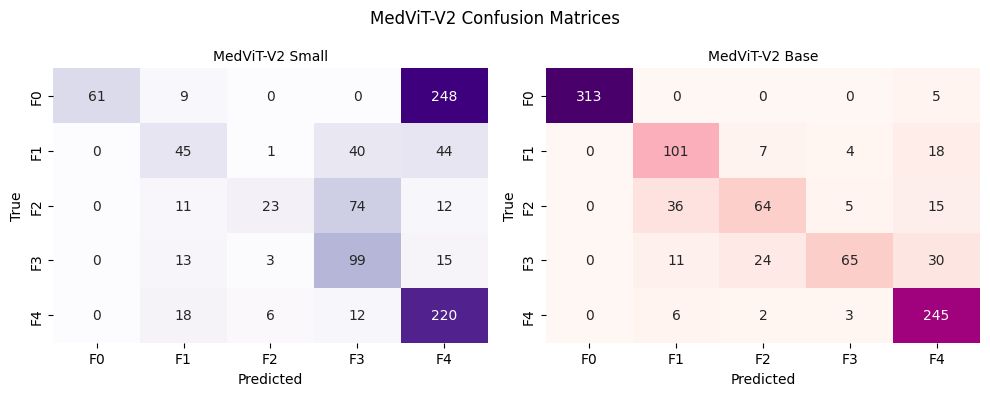

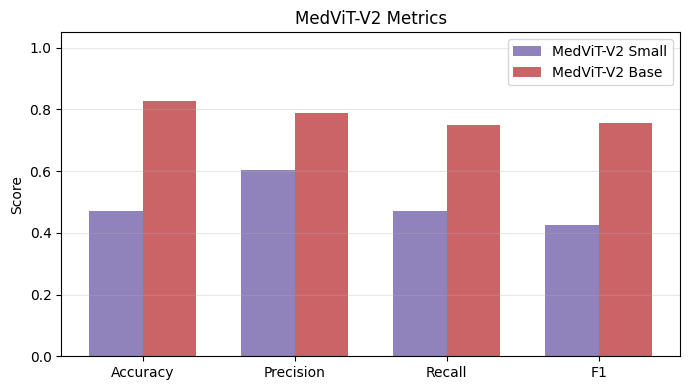

MedViT-V2 figures saved.


In [8]:
for mod in list(sys.modules.keys()):
    if 'MedViT' in mod:
        del sys.modules[mod]

v1_path = os.path.abspath('MedViT')
if v1_path in sys.path:
    sys.path.remove(v1_path)
if os.path.abspath('MedViTV2') not in sys.path:
    sys.path.insert(0, os.path.abspath('MedViTV2'))

from MedViT import MedViT_small as V2_small, MedViT_base as V2_base

v2_entries = [
    ('MedViT-V2 Small', V2_small, 'medvit_v2_small.pth'),
    ('MedViT-V2 Base',  V2_base,  'medvit_v2_base.pth'),
]
v2_names = []
for name, cls, path in v2_entries:
    m = cls(num_classes=N_CLASSES)
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    inc = m.load_state_dict(ckpt, strict=False)
    if len(inc.missing_keys) > len(list(m.parameters())) * 0.5:
        print(f'{name}: architecture mismatch, skipping.')
        continue
    m = m.to(device)
    results[name] = evaluate(m, test_loader)
    v2_names.append(name)
    print(f'{name}: acc={results[name]["accuracy"]:.4f}  f1={results[name]["f1"]:.4f}')

if v2_names:
    fig, axes = plt.subplots(1, len(v2_names), figsize=(5 * len(v2_names), 4))
    if len(v2_names) == 1: axes = [axes]
    for ax, name, cmap in zip(axes, v2_names, ['Purples', 'RdPu']):
        sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap=cmap,
                    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
        ax.set_title(name, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.suptitle('MedViT-V2 Confusion Matrices', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/cm_medvit_v2_group.png', dpi=150)
    plt.show()

    x = np.arange(len(metrics)); width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, (name, color) in enumerate(zip(v2_names, ['#8172B2', '#C44E52'])):
        ax.bar(x + i * width, [results[name][m] for m in metrics], width, label=name, color=color, alpha=0.88)
    ax.set_xticks(x + width / 2); ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('MedViT-V2 Metrics')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/metrics_medvit_v2.png', dpi=150)
    plt.show()
    print('MedViT-V2 figures saved.')

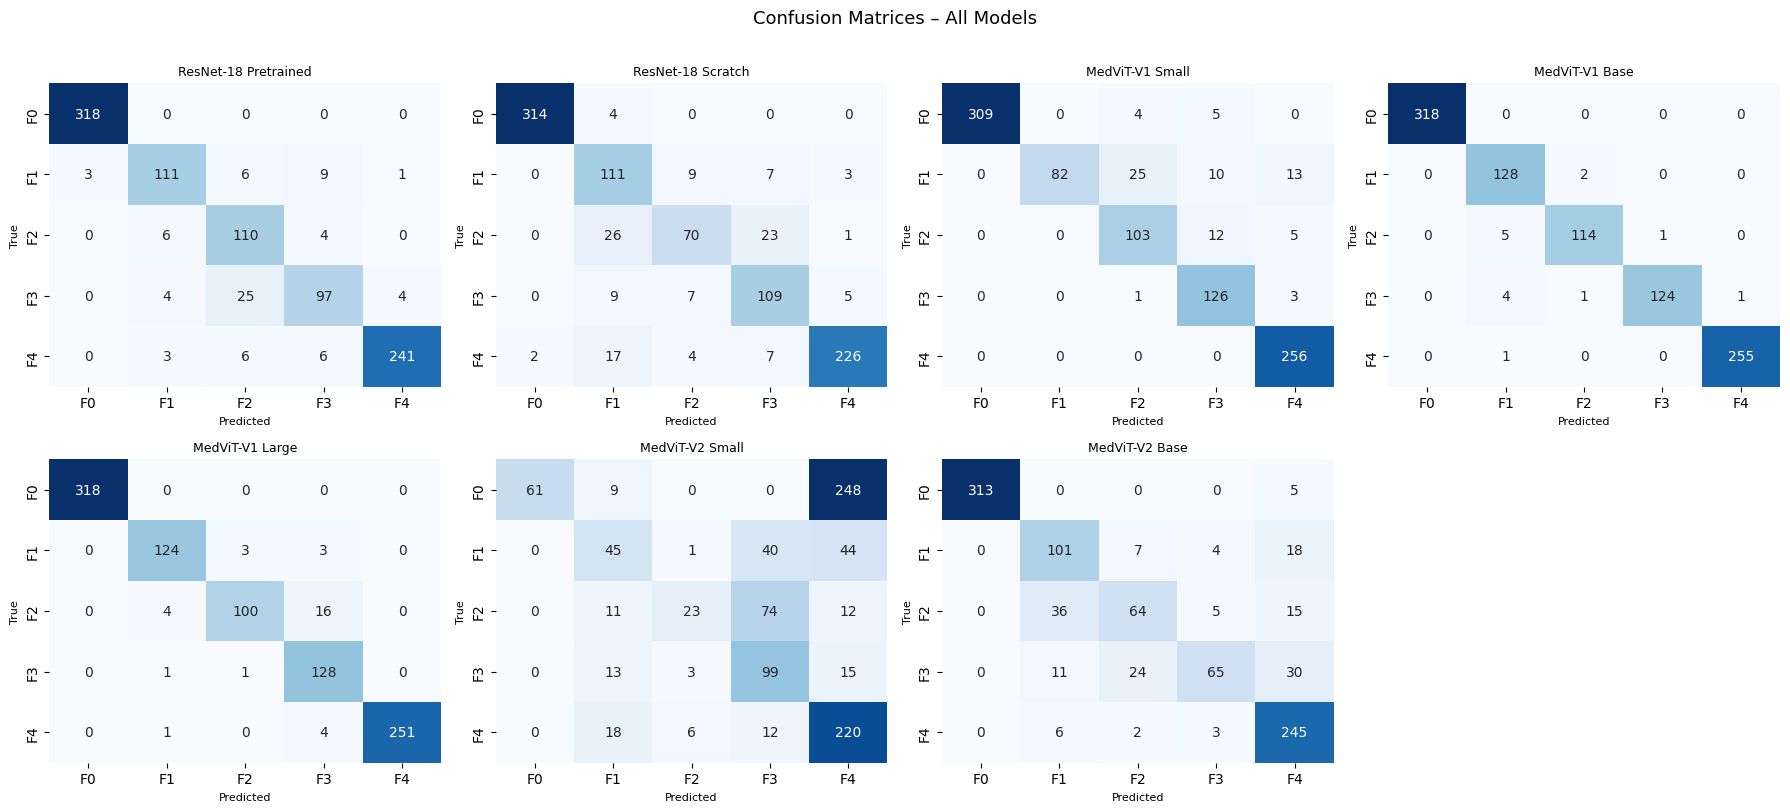

Saved confusion_all.png


In [9]:
model_names = list(results.keys())
n = len(model_names)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
axes = axes.flatten()

for i, name in enumerate(model_names):
    sns.heatmap(results[name]['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[i], cbar=False)
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('True', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices – All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/confusion_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_all.png')

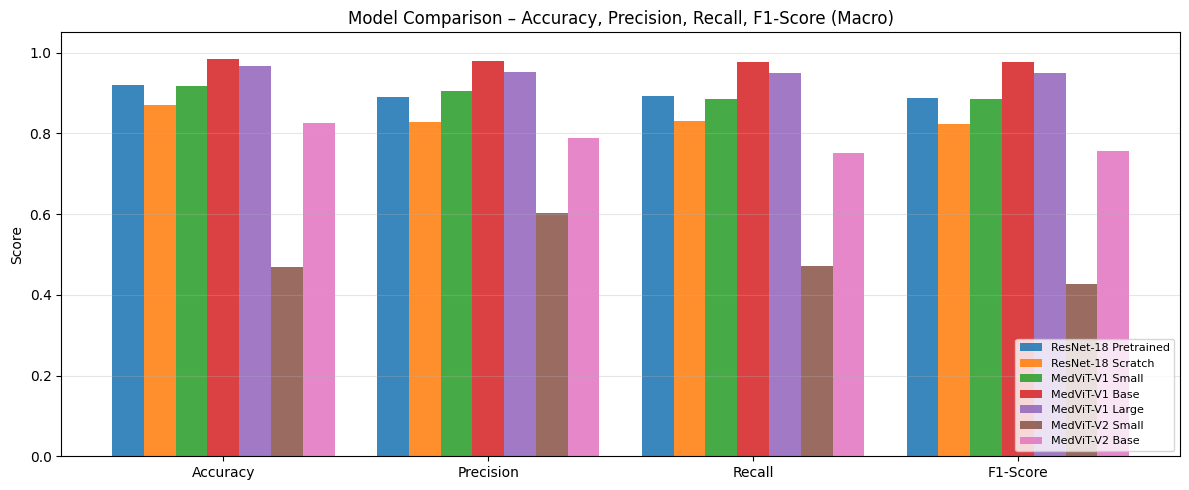

Saved metrics_comparison.png


In [10]:
metrics      = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x            = np.arange(len(metrics))
width        = 0.12
palette      = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name, color=palette[i], alpha=0.88)

ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Accuracy, Precision, Recall, F1-Score (Macro)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/metrics_comparison.png', dpi=150)
plt.show()
print('Saved metrics_comparison.png')

In [11]:
header = f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}"
print(header)
print('-' * 68)
for name, res in results.items():
    print(f"{name:<25} {res['accuracy']:>10.4f} {res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")

Model                       Accuracy  Precision     Recall         F1
--------------------------------------------------------------------
ResNet-18 Pretrained          0.9193     0.8900     0.8916     0.8884
ResNet-18 Scratch             0.8700     0.8289     0.8292     0.8230
MedViT-V1 Small               0.9182     0.9044     0.8860     0.8849
MedViT-V1 Base                0.9843     0.9780     0.9769     0.9772
MedViT-V1 Large               0.9654     0.9526     0.9505     0.9496
MedViT-V2 Small               0.4696     0.6028     0.4701     0.4264
MedViT-V2 Base                0.8260     0.7885     0.7503     0.7565
